**Nombre del estudiante:**

### **Práctica: Introducción al Aprendizaje Profundo con dataset `digits`**

**Duración estimada:** 100–140 minutos (ejecución completa por bloques).

**Objetivo general:** Aplicar y experimentar con conceptos clave de deep learning —inicialización de pesos, funciones de activación, optimizadores y regularización— construyendo y comparando MLPs sobre el dataset `digits` (imágenes \(8\times8\)). Evaluar comportamiento de entrenamiento/validación, analizar el fenómeno del gradiente desvaneciente y proponer intervenciones para recuperar el aprendizaje.

**Resultados esperados**
- Notebook reproducible con celdas ejecutables.
- Visualizaciones: ejemplos del dataset, curvas de loss/accuracy, matriz de confusión.
- Comparativa entre optimizadores: SGD, SGD+momentum, RMSProp, Adam.
- Experimento “ruptura” (deep + sigmoid + SGD) que demuestre colapso del gradiente.
- Análisis matemático breve usando las ecuaciones de backpropagation y la conservación de varianza.
- Desafío final con rúbrica de evaluación.

**Estructura de la práctica (bloques)**
- **Bloque A — Preparación y exploración de datos** (15 min): carga, normalización, visualización de ejemplos y particionado train/val/test.  
- **Bloque B — Modelo base** (20–25 min): MLP con ReLU + He + Adam; entrenamiento y gráficas.  
- **Bloque C — Comparativa de optimizadores** (25 min): entrenar misma arquitectura con varios optimizadores y comparar curvas.  
- **Bloque D — Experimento ruptura** (20–30 min): 5 capas, activación sigmoid, optimizador SGD; medir gradientes por capa y documentar colapso.  


**Indicaciones prácticas**
- Mantén semillas fijas para reproducibilidad (`tf.random.set_seed`, `np.random.seed`).
- Normaliza entradas a rango \([0,1]\) antes de entrenar.
- Usa `sparse_categorical_crossentropy` para etiquetas enteras.
- Registra y guarda `history` para todas las corridas para comparar curvas.
- Para el experimento de gradientes, calcula magnitud media de gradientes por capa en epochs seleccionadas.

**Entregable mínimo**
- Notebook con celdas ejecutadas, gráficas y un notas que explique observaciones y justifique las intervenciones propuestas.


X_train: (1257, 64), y_train: (1257,)
X_val:   (270, 64), y_val:   (270,)
X_test:  (270, 64), y_test:  (270,)


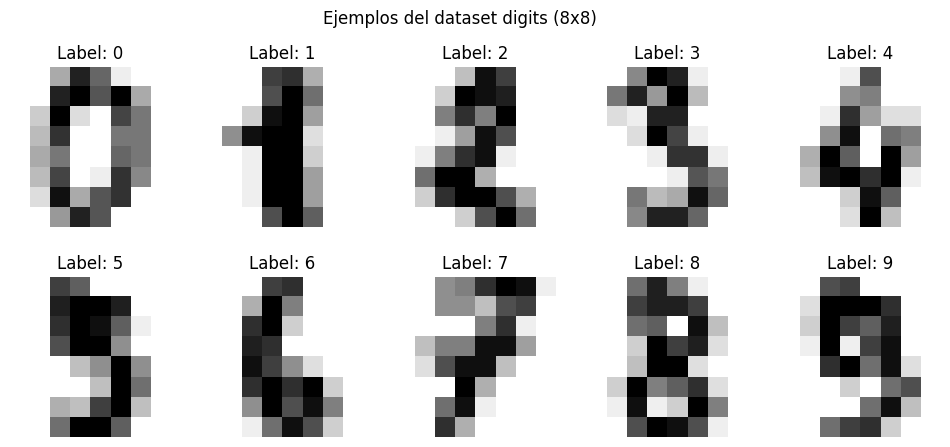

Clase 0: 178 ejemplos
Clase 1: 182 ejemplos
Clase 2: 177 ejemplos
Clase 3: 183 ejemplos
Clase 4: 181 ejemplos
Clase 5: 182 ejemplos
Clase 6: 181 ejemplos
Clase 7: 179 ejemplos
Clase 8: 174 ejemplos
Clase 9: 180 ejemplos


In [8]:
# Carga y exploración del dataset 'digits' (copia y pega en Colab)
# Duración estimada de ejecución: ~1-2 minutos

# 1) Imports y semillas para reproducibilidad
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

# 2) Carga y normalización (rango 0-1)
digits = load_digits()
X = digits.data.astype(np.float32) / 16.0   # cada píxel en 0..16 -> normalizamos a 0..1
y = digits.target

# 3) Particionado: train / val / test (70% / 15% / 15%) con estratificación
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# 4) Visualización rápida de ejemplos (10 imágenes)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    img = digits.images[i]            # forma (8,8)
    label = digits.target[i]
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.suptitle("Ejemplos del dataset digits (8x8)")
plt.show()

# 5) Distribución de clases (comprobación rápida)
(unique, counts) = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Clase {u}: {c} ejemplos")



Tarea: Comenta el paso a paso del codigo anterior y cual es el resultado de salida

### Ecuaciones y explicación detallada para la práctica

**Objetivo:** presentar de forma compacta y ejecutable las fórmulas matemáticas que usaremos en el notebook, con su interpretación práctica para los experimentos (inicialización, activaciones, optimizadores y colapso del gradiente).

---

### Forward pass por capa
La operación básica en la capa $l$ consta de una suma ponderada (pre‑activación) y una función no lineal (activación):

$z^{(l)} = W^{(l)}\,a^{(l-1)} + b^{(l)}$  
$a^{(l)} = \phi\big(z^{(l)}\big)$

donde **$a^{(0)}=x$** es la entrada del modelo y $\phi$ es la función de activación (por ejemplo $\mathrm{ReLU}$ o $\sigma$).

---

### Salida y función de pérdida (clasificación multiclase)
La capa final produce logits $z^{(L)}$ que se convierten en probabilidades con **softmax**:

$$
\hat{p}_k = \mathrm{softmax}(z)_k = \frac{e^{z_k}}{\sum_j e^{z_j}}
$$

La pérdida por muestra con entropía cruzada es:

$$
\ell(\hat{p}, y) = -\sum_{k} y_k \log \hat{p}_k
$$

Usamos **sparse_categorical_crossentropy** cuando las etiquetas son enteros.

---

### Backpropagation: error local y gradientes
Definimos el **error local** (delta) en la capa $l$ y su regla recursiva hacia atrás:

$$
\delta^{(L)} = \nabla_{a^{(L)}} \ell \odot \phi'(z^{(L)})
\qquad
\delta^{(l)} = \big(W^{(l+1)}\big)^{T}\delta^{(l+1)} \odot \phi'(z^{(l)})
$$

La ecuación BP4 (gradiente respecto a los pesos) es:

$$
\nabla_{W^{(l)}} \ell \;=\; \delta^{(l)} \, \big(a^{(l-1)}\big)^{T}
$$

**Interpretación:** la magnitud de la corrección de $W^{(l)}$ depende de la **fuerza del error local** $\delta^{(l)}$ y de la **energía de la entrada** $a^{(l-1)}$.

---

### Derivadas de activaciones relevantes
- **Sigmoide** $\sigma(z)$:  
  $ \sigma'(z)=\sigma(z)\big(1-\sigma(z)\big) \le 0.25 $.  
  *Consecuencia:* en regiones saturadas $\sigma'(z)\approx 0$ y $\delta^{(l)}$ se atenúa.

- **ReLU**:  
  $\mathrm{ReLU}(z)=\max(0,z)$ y  
  $\mathrm{ReLU}'(z)=\begin{cases}1 & z>0\\0 & z\le 0\end{cases}$.  
  *Consecuencia:* para $z>0$ la derivada no atenúa el gradiente, lo que ayuda a mitigar el desvanecimiento.

---

### Conservación de varianza e inicialización de pesos
Para que la señal no colapse ni explote a través de capas, la varianza de las activaciones debe permanecer estable. Aproximación:

$$
\mathrm{Var}(z) \approx n_{\text{in}}\cdot\mathrm{Var}(w)\cdot\mathrm{Var}(a)
$$

Regla práctica para mantener la varianza:  
$$
n_{\text{in}}\cdot\mathrm{Var}(w) \approx 1
$$

- **Inicialización Xavier / Glorot** (adecuada para tanh/sigmoid):  
  $$\mathrm{Var}(w) \approx \frac{1}{n_{\text{in}}} \quad\text{o}\quad \frac{2}{n_{\text{in}}+n_{\text{out}}}.$$

- **Inicialización He (Kaiming)** (adecuada para ReLU):  
  $$\mathrm{Var}(w) = \frac{2}{n_{\text{in}}}.$$

**Motivo:** ReLU anula aproximadamente la mitad de las activaciones (valores negativos), por eso He compensa multiplicando la varianza por 2.

---

### Gradiente desvaneciente y su conexión con BP4
Si $\phi'(z^{(l)})$ es pequeño (p. ej. sigmoide saturada), entonces cada multiplicación por $\phi'$ en la regla recursiva reduce la magnitud de $\delta$:

$$
\delta^{(l)} = \big(W^{(l+1)}\big)^{T}\delta^{(l+1)} \odot \phi'(z^{(l)})
$$

Después de varias capas esto puede producir una **decadencia exponencial** de $\delta$ hacia las capas iniciales. Como consecuencia, por la ecuación BP4:

$$
\nabla_{W^{(l)}} \ell = \delta^{(l)} (a^{(l-1)})^T \approx 0
$$

y las primeras capas **no actualizan** sus pesos de forma significativa: esto es el **gradiente desvaneciente**.

---

### Recomendaciones prácticas para los experimentos
- **Arquitectura de referencia:** usar ReLU en ocultas con `kernel_initializer=HeNormal()` y un L2 ligero + Dropout para controlar varianza y overfitting.  
- **Si usas sigmoid/tanh:** emplea inicialización Glorot y reduce la profundidad o añade BatchNormalization / skip connections.  
- **Optimizadores:** Adam o RMSProp aceleran convergencia y ayudan cuando los gradientes son ruidosos; SGD puro puede ser más estable pero más lento.  
- **Diagnóstico de colapso:** monitorizar curvas de loss/accuracy y calcular la magnitud media de los gradientes por capa en epochs tempranas y tardías. Si las magnitudes en capas iniciales son cercanas a cero, hay desvanecimiento.



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_128_relu_he (Dense)       │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_0.3 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_64_relu_he (Dense)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_0.2 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_softmax (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
40/40 - 2s - 44ms/step - accuracy: 0.2411 - loss: 2.1412 - val_accuracy: 0.7519 - val_loss: 1.5962
Epoch 2/30
40/40 - 0s - 6ms/step - accuracy: 0.6261 - loss: 1.3690 - val_accuracy: 0.8519 - val_loss: 0.8484
Epoch 3/30
40/40 - 0s - 5ms/step - accuracy: 0.7518 - loss: 0.8742 - val_accuracy: 0.9000 - val_loss: 0.5303
Epoch 4/30
40/40 - 0s - 5ms/step - accuracy: 0.8019 - loss: 0.6548 - val_accuracy: 0.9185 - val_loss: 0.4088
Epoch 5/30
40/40 - 0s - 5ms/step - accuracy: 0.8512 - loss: 0.5241 - val_accuracy: 0.9296 - val_loss: 0.3357
Epoch 6/30
40/40 - 0s - 5ms/step - accuracy: 0.8783 - loss: 0.4277 - val_accuracy: 0.9407 - val_loss: 0.2870
Epoch 7/30
40/40 - 0s - 5ms/step - accuracy: 0.8831 - loss: 0.3880 - val_accuracy: 0.9444 - val_loss: 0.2468
Epoch 8/30
40/40 - 0s - 5ms/step - accuracy: 0.9021 - loss: 0.3529 - val_accuracy: 0.9407 - val_loss: 0.2253
Epoch 9/30
40/40 - 0s - 5ms/step - accuracy: 0.9196 - loss: 0.2935 - val_accuracy: 0.9444 - val_loss: 0.2083
Epoch 10/30
40/40 

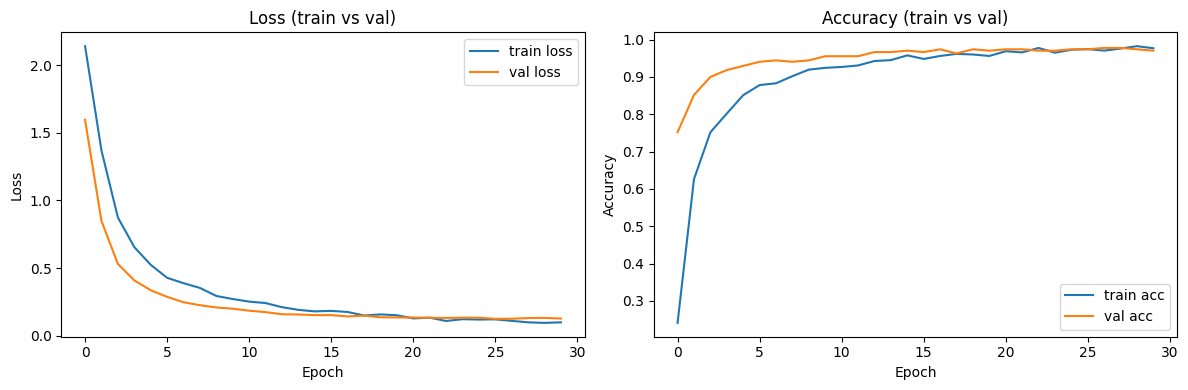


Test loss: 0.0777  |  Test accuracy: 0.9889
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


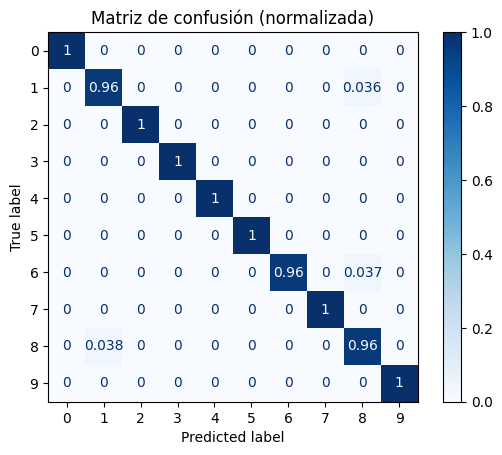


Reporte de clasificación (precision / recall / f1):

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        27
           1     0.9643    0.9643    0.9643        28
           2     1.0000    1.0000    1.0000        26
           3     1.0000    1.0000    1.0000        28
           4     1.0000    1.0000    1.0000        27
           5     1.0000    1.0000    1.0000        27
           6     1.0000    0.9630    0.9811        27
           7     1.0000    1.0000    1.0000        27
           8     0.9259    0.9615    0.9434        26
           9     1.0000    1.0000    1.0000        27

    accuracy                         0.9889       270
   macro avg     0.9890    0.9889    0.9889       270
weighted avg     0.9892    0.9889    0.9890       270



In [3]:
# Modelo base: ReLU + HeNormal + Adam
# (asume que X_train, X_val, X_test, y_train, y_val, y_test ya están definidos)

import tensorflow as tf
from tensorflow.keras import layers, models, initializers, regularizers, callbacks
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import numpy as np

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# 1) Construcción del modelo
def build_model_relu_he(input_dim=64, l2=1e-4):
    model = models.Sequential([
        layers.InputLayer(input_shape=(input_dim,)),
        layers.Dense(128, activation='relu',
                     kernel_initializer=initializers.HeNormal(),
                     kernel_regularizer=regularizers.l2(l2),
                     name="Dense_128_relu_he"),
        layers.Dropout(0.3, name="Dropout_0.3"),
        layers.Dense(64, activation='relu',
                     kernel_initializer=initializers.HeNormal(),
                     name="Dense_64_relu_he"),
        layers.Dropout(0.2, name="Dropout_0.2"),
        layers.Dense(10, activation='softmax', name="Output_softmax")
    ])
    return model

# 2) Compilación
model = build_model_relu_he()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3) Resumen del modelo
model.summary()

# 4) Callbacks (opcional: EarlyStopping para evitar overfitting extremo)
es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 5) Entrenamiento
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[es],
    verbose=2
)

# 6) Visualización de curvas de pérdida y accuracy
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss (train vs val)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy (train vs val)')
plt.legend()
plt.tight_layout()
plt.show()

# 7) Evaluación final en el conjunto de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

# 8) Matriz de confusión y reporte de clasificación
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', normalize='true')
disp.ax_.set_title("Matriz de confusión (normalizada)")
plt.show()

print("\nReporte de clasificación (precision / recall / f1):\n")
print(classification_report(y_test, y_pred, digits=4))

# 9) Guardar history para comparaciones posteriores
history_base = history


**Tarea - Describe e interpreta los resultados obtenidos:**

### Comparativa de Optimizadores

**Propósito**  
Breve experimento para comparar la convergencia y estabilidad de **SGD**, **SGD+momentum**, **RMSProp** y **Adam** usando la misma arquitectura de referencia (ReLU + He + Dropout). Observaremos curvas de validación, métricas finales y tiempo por entrenamiento.

**Qué hará la celda siguiente**  
- Entrenará la misma red con cuatro optimizadores distintos.  
- Guardará los historiales de entrenamiento para trazar **val_accuracy** y **val_loss**.  
- Evaluará cada modelo en el conjunto de prueba e imprimirá un resumen con **test_acc**, **test_loss** y **tiempo de entrenamiento**.

**Instrucciones antes de ejecutar**  
- Asegúrate de haber ejecutado las celdas previas que definen: `X_train, X_val, X_test, y_train, y_val, y_test`.  
- Mantén la salida de la celda para comparar las gráficas y la tabla resumen que se imprimirán.  
- Si quieres limitar el tiempo, reduce `epochs` en la celda siguiente (por ejemplo a 15).

**Qué registrar y comentar después de ejecutar**  
- Valores finales de **val_accuracy** por optimizador.  
- ¿Cuál converge más rápido? ¿Cuál es más estable?  
- Observaciones sobre diferencias en tiempo por epoch o comportamiento ruidoso en las curvas.



--- Training with SGD ---
SGD -> test_acc: 0.9259  test_loss: 0.3838  time(s): 5.54

--- Training with SGD_mom ---
SGD_mom -> test_acc: 0.9815  test_loss: 0.0907  time(s): 5.77

--- Training with RMSProp ---
RMSProp -> test_acc: 0.9889  test_loss: 0.0724  time(s): 6.30

--- Training with Adam ---
Adam -> test_acc: 0.9852  test_loss: 0.0788  time(s): 6.66


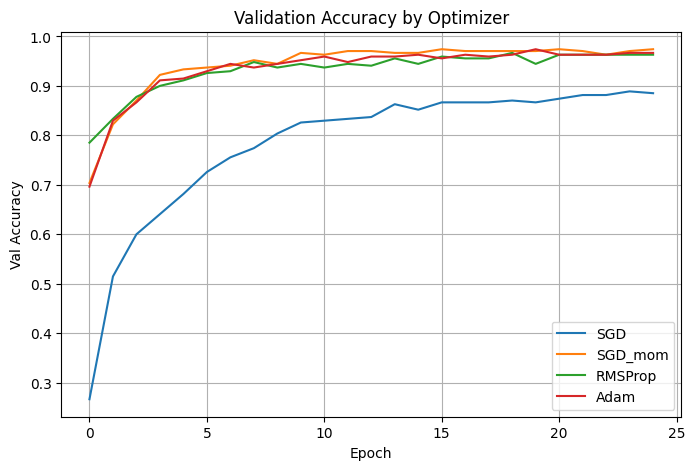

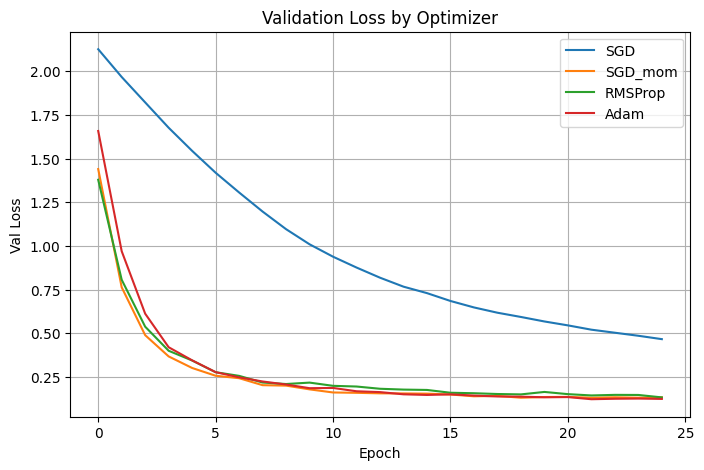


Resumen de resultados por optimizador:

         test_acc  test_loss  time_s
SGD        0.9259     0.3838  5.5448
SGD_mom    0.9815     0.0907  5.7666
RMSProp    0.9889     0.0724  6.3049
Adam       0.9852     0.0788  6.6581


In [4]:
# Comparativa de optimizadores: SGD, SGD+momentum, RMSProp, Adam
# Asume X_train, X_val, X_test, y_train, y_val, y_test ya definidos

import tensorflow as tf
from tensorflow.keras import layers, models, initializers, regularizers
import numpy as np
import matplotlib.pyplot as plt
import time

tf.random.set_seed(42)
np.random.seed(42)

def build_model_relu_he(input_dim=64, l2=1e-4):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_initializer=initializers.HeNormal(),
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    return model

optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD_mom': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

results = {}
histories = {}

for name, opt in optimizers.items():
    tf.keras.backend.clear_session()
    model = build_model_relu_he()
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f"\n--- Training with {name} ---")
    start = time.time()
    h = model.fit(X_train, y_train, epochs=25, batch_size=32,
                  validation_data=(X_val, y_val), verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name} -> test_acc: {test_acc:.4f}  test_loss: {test_loss:.4f}  time(s): {elapsed:.2f}")
    results[name] = {'test_acc': test_acc, 'test_loss': test_loss, 'time_s': elapsed}
    histories[name] = h

# Plot validation accuracy comparison
plt.figure(figsize=(8,5))
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.title('Validation Accuracy by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot validation loss comparison
plt.figure(figsize=(8,5))
for name, h in histories.items():
    plt.plot(h.history['val_loss'], label=name)
plt.title('Validation Loss by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend()
plt.grid(True)
plt.show()

# Print summary table
import pandas as pd
df = pd.DataFrame(results).T
df = df[['test_acc','test_loss','time_s']]
print("\nResumen de resultados por optimizador:\n")
print(df.round(4))


**Tarea - Describe e interpreta los resultados obtenidos:**

## **Experimento ruptura 5 capas sigmoid SGD**

**Propósito**  
Entrenar una red intencionalmente propensa al gradiente desvaneciente para observar empíricamente cómo las magnitudes de los gradientes se atenúan hacia las capas iniciales y cómo esto impacta las actualizaciones de pesos.

---

### Configuración experimental (resumen)
- **Arquitectura:** 5 capas ocultas densas de 64 neuronas cada una.  
- **Activación:** `sigmoid` en todas las capas ocultas.  
- **Inicialización:** `GlorotNormal` (Xavier).  
- **Optimizador:** `SGD(learning_rate=0.01)` sin momentum.  
- **Entrenamiento:** `epochs=30`, `batch_size=32`.  
- **Medición clave:** magnitud media absoluta de los gradientes de los **kernels** por capa en cada epoch.

---

### Formulación matemática esencial

**Forward pass por capa $l$**  
$z^{(l)} = W^{(l)}\,a^{(l-1)} + b^{(l)}$  
$a^{(l)} = \phi\big(z^{(l)}\big)$  
donde $a^{(0)}=x$.

**Salida y pérdida (softmax + cross entropy)**  
$$
\hat{p}_k = \mathrm{softmax}(z)_k = \frac{e^{z_k}}{\sum_j e^{z_j}}
$$
$$
\ell(\hat{p}, y) = -\sum_{k} y_k \log \hat{p}_k
$$

**Backpropagation y ecuación BP4**  
Error de salida y regla recursiva:
$$
\delta^{(L)} = \nabla_{a^{(L)}} \ell \odot \phi'(z^{(L)})
\qquad
\delta^{(l)} = \big(W^{(l+1)}\big)^{T}\delta^{(l+1)} \odot \phi'(z^{(l)})
$$
Gradiente respecto a los pesos (BP4):
$$
\nabla_{W^{(l)}} \ell \;=\; \delta^{(l)} \, \big(a^{(l-1)}\big)^{T}
$$

**Derivada de la sigmoide**  
$ \sigma'(z)=\sigma(z)\big(1-\sigma(z)\big) \le 0.25 $.  
*Implicación:* en regiones saturadas $\sigma'(z)\approx 0$ y $\delta^{(l)}$ se atenúa.

**Conservación de varianza e inicialización**  
Para evitar colapso o explosión de la señal:
$$
\mathrm{Var}(z) \approx n_{\text{in}}\cdot\mathrm{Var}(w)\cdot\mathrm{Var}(a)
$$
Regla práctica: $n_{\text{in}}\cdot\mathrm{Var}(w)\approx 1$.  
Xavier (Glorot) está diseñado para activaciones tipo tanh/sigmoid; sin embargo, en redes profundas y con funciones que saturan, la multiplicación repetida por derivadas pequeñas puede provocar desvanecimiento.

---

### Hipótesis y expectativas
- **Hipótesis principal:** con `sigmoid` y 5 capas profundas, las derivadas $\phi'(z^{(l)})$ serán pequeñas en muchas neuronas; por la regla recursiva, $\delta^{(l)}$ se reducirá exponencialmente hacia las capas iniciales.  
- **Efecto observable en BP4:** si $\delta^{(l)}$ es cercano a cero, entonces $\nabla_{W^{(l)}} \ell \approx 0$ y las primeras capas no actualizarán sus kernels de forma significativa.  
- **Señales empíricas esperadas:** curvas de validación estancadas o muy lentas; magnitud media absoluta de gradientes por capa decreciente desde las capas superiores hacia las inferiores (ver gráfico en escala log).

---

### Qué registrar durante la ejecución
- **`grad_means[epoch, layer]`**: magnitud media absoluta de los gradientes del kernel por capa (usar escala log para visualizar órdenes de magnitud).  
- **Curvas**: `val_loss` y `val_accuracy` por epoch.  
- **Evaluación final**: `test_loss` y `test_accuracy`.  
- **Observación cualitativa**: ¿las capas 1–2 muestran gradientes varios órdenes de magnitud menores que las capas superiores?

---

### Interpretación de resultados y preguntas formativas
- Si observas que las magnitudes de gradiente en las capas iniciales son ~0 comparadas con las capas superiores, explica usando la ecuación:
  $$\delta^{(l)} = \big(W^{(l+1)}\big)^{T}\delta^{(l+1)} \odot \sigma'(z^{(l)})$$
  ¿Qué papel juega $\sigma'(z^{(l)})$ en esa atenuación?  
- Relaciona la observación con la conservación de varianza: ¿la inicialización Xavier fue suficiente para mantener la señal estable a través de 5 capas con sigmoide?  
- Propón dos intervenciones concretas para recuperar el aprendizaje y justifica matemáticamente cada una (por ejemplo: cambiar a ReLU+He, añadir BatchNormalization, usar SGD+momentum o Adam, o introducir skip connections).

---

### Sugerencia de análisis posterior
1. **Comparar gradientes**: calcula la razón entre la magnitud media de la capa superior y la capa inferior en la epoch 1 y en la epoch final.  
2. **Visualizar activaciones**: inspecciona la distribución de $z^{(l)}$ y $a^{(l)}$ en una mini-batch para detectar saturación (valores cercanos a 0 o 1 en sigmoide).  
3. **Probar intervenciones**: aplica una intervención (por ejemplo ReLU+He) y repite el experimento para comparar `grad_means` y `val_accuracy`.

---




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_sigmoid_1 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_sigmoid_2 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_sigmoid_3 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_sigmoid_4 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_sigmoid_5 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,450 (83.79 KB)

 Trainable params: 21,450 (83.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30  val_loss: 2.3977  val_acc: 0.0963  grad_means (first 3): 1.0276e-05, 5.5724e-05, 2.1107e-04
Epoch 2/30  val_loss: 2.3285  val_acc: 0.0963  grad_means (first 3): 9.8872e-06, 4.8575e-05, 1.8961e-04
Epoch 3/30  val_loss: 2.3088  val_acc: 0.0963  grad_means (first 3): 9.8769e-06, 4.8104e-05, 1.8634e-04
Epoch 4/30  val_loss: 2.3039  val_acc: 0.1000  grad_means (first 3): 9.9384e-06, 4.8171e-05, 1.8685e-04
Epoch 5/30  val_loss: 2.3029  val_acc: 0.1000  grad_means (first 3): 1.0024e-05, 4.9192e-05, 1.8954e-04
Epoch 6/30  val_loss: 2.3031  val_acc: 0.1000  grad_means (first 3): 1.0049e-05, 4.9559e-05, 1.8995e-04
Epoch 7/30  val_loss: 2.3030  val_acc: 0.1000  grad_means (first 3): 1.0076e-05, 4.9653e-05, 1.9164e-04
Epoch 8/30  val_loss: 2.3029  val_acc: 0.1000  grad_means (first 3): 1.0122e-05, 5.0090e-05, 1.9311e-04
Epoch 9/30  val_loss: 2.3028  val_acc: 0.1000  grad_means (first 3): 1.0167e-05, 5.0733e-05, 1.9459e-04
Epoch 10/30  val_loss: 2.3027  val_acc: 0.1000  grad_means (firs

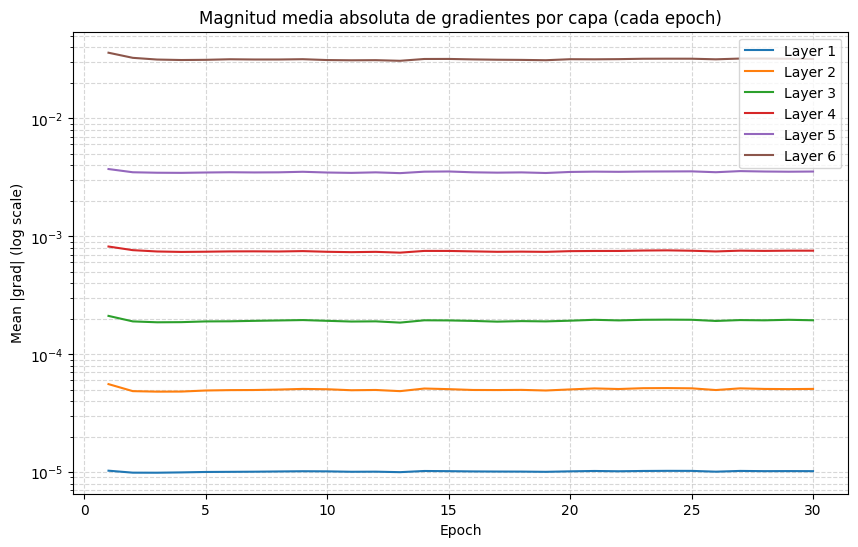

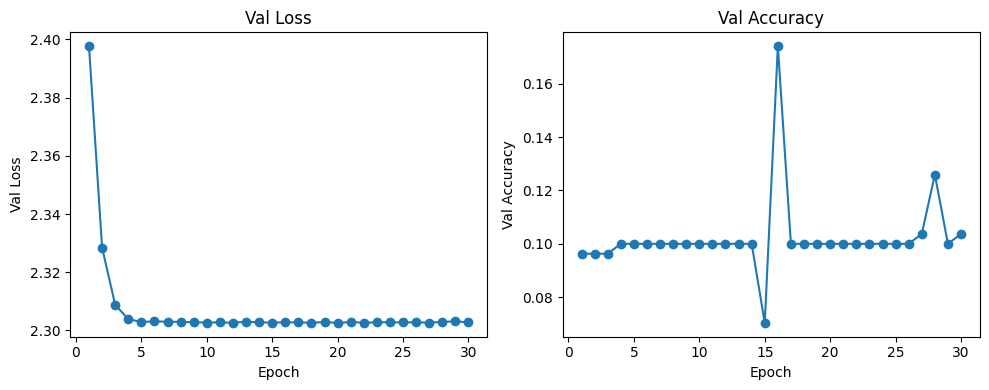


Test loss: 2.3027  |  Test accuracy: 0.1000


In [5]:
# Experimento ruptura: 5 capas sigmoid + Glorot + SGD
# ejecutar en Colab (asume X_train, X_val, X_test, y_train, y_val, y_test ya definidos)

import tensorflow as tf
from tensorflow.keras import layers, models, initializers
import numpy as np
import matplotlib.pyplot as plt
import time

tf.random.set_seed(42)
np.random.seed(42)

# 1) Construcción del modelo "rotura"
def build_broken_model(input_dim=64, n_hidden=5, hidden_units=64):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for i in range(n_hidden):
        model.add(layers.Dense(hidden_units, activation='sigmoid',
                               kernel_initializer=initializers.GlorotNormal(),
                               name=f"dense_sigmoid_{i+1}"))
    model.add(layers.Dense(10, activation='softmax', name="output_softmax"))
    return model

# 2) Compilación
tf.keras.backend.clear_session()
broken = build_broken_model()
broken.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
broken.summary()

# 3) Preparar estructura para registrar gradientes por capa por epoch
# Identificamos las variables de peso (no biases) por capa para agrupar por capa densa
weight_vars = [w for w in broken.trainable_weights if 'kernel' in w.name]
n_layers = len(weight_vars)

epochs = 30
batch_size = 32

# Arrays para almacenar magnitudes medias de gradiente por epoch y por capa
grad_means = np.zeros((epochs, n_layers))
val_acc = []
val_loss = []

# 4) Entrenamiento manual por epoch para capturar gradientes (usando batches)
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024, seed=42).batch(batch_size)
val_data = (X_val, y_val)

start_time = time.time()
for ep in range(epochs):
    # entrenamiento por batches
    for step, (xb, yb) in enumerate(dataset):
        with tf.GradientTape() as tape:
            preds = broken(xb, training=True)
            loss_value = tf.keras.losses.sparse_categorical_crossentropy(yb, preds)
            loss_value = tf.reduce_mean(loss_value)
        grads = tape.gradient(loss_value, broken.trainable_weights)
        # Aplicar actualización manual con el optimizador (para mantener comportamiento idéntico)
        broken.optimizer.apply_gradients(zip(grads, broken.trainable_weights))
    # Al final de la epoch, calculamos la magnitud media absoluta de los gradientes sobre una mini-batch fija
    xb = X_train[:batch_size]
    yb = y_train[:batch_size]
    with tf.GradientTape() as tape:
        preds = broken(xb, training=True)
        loss_value = tf.keras.losses.sparse_categorical_crossentropy(yb, preds)
        loss_value = tf.reduce_mean(loss_value)
    grads_epoch = tape.gradient(loss_value, broken.trainable_weights)
    # Extraer magnitud media absoluta por variable de kernel y agrupar por capa
    kernel_grads = [g for (g, w) in zip(grads_epoch, broken.trainable_weights) if 'kernel' in w.name]
    for i, g in enumerate(kernel_grads):
        grad_means[ep, i] = tf.reduce_mean(tf.abs(g)).numpy()
    # Evaluación en validación
    metrics = broken.evaluate(X_val, y_val, verbose=0)
    val_loss.append(metrics[0])
    val_acc.append(metrics[1])

    # Fix for f-string error: Format the first 3 gradient means individually
    grad_means_first_3_formatted = ", ".join([f"{g:.4e}" for g in grad_means[ep, :min(3, n_layers)]])
    print(f"Epoch {ep+1}/{epochs}  val_loss: {metrics[0]:.4f}  val_acc: {metrics[1]:.4f}  grad_means (first {min(3, n_layers)}): {grad_means_first_3_formatted}")

elapsed = time.time() - start_time
print(f"\nTiempo total entrenamiento: {elapsed:.2f}s")

# 5) Plots: gradientes por capa a lo largo de las epochs
plt.figure(figsize=(10,6))
for i in range(n_layers):
    plt.plot(range(1, epochs+1), grad_means[:, i], label=f'Layer {i+1}')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Mean |grad| (log scale)')
plt.title('Magnitud media absoluta de gradientes por capa (cada epoch)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

# 6) Curvas de validación
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), val_loss, '-o')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.title('Val Loss')

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), val_acc, '-o')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.title('Val Accuracy')
plt.tight_layout()
plt.show()

# 7) Evaluación final en test
test_loss, test_acc = broken.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

### Intervención A ReLU He SGD momentum

**Objetivo**  
Cambiar la arquitectura para eliminar el gradiente desvaneciente observado con `sigmoid` y Xavier, recuperando flujo de gradiente y aprendizaje estable.

**Cambios aplicados**  
- **Activación:** reemplazar `sigmoid` por **ReLU** en todas las capas ocultas.  
- **Inicialización:** usar **HeNormal** (`kernel_initializer=HeNormal`) en capas con ReLU.  
- **Optimizador:** usar **SGD** con **momentum=0.9** (`SGD(learning_rate=0.01, momentum=0.9)`).  
- Mantener el resto (número de capas, unidades, batch_size, epochs) para comparar directamente.

**Justificación matemática breve**  
- ReLU tiene derivada $\mathrm{ReLU}'(z)=1$ para $z>0$, por lo que no atenúa el gradiente en regiones activas.  
- He compensa la pérdida de varianza por el truncamiento de valores negativos: $$\mathrm{Var}(w)=\frac{2}{n_{\text{in}}}.$$  
- Momentum acumula dirección y ayuda a superar regiones con gradientes pequeños, acelerando la convergencia.

**Qué esperamos observar**  
- **Gradientes por capa:** las magnitudes medias absolutas (`grad_means`) en capas iniciales aumentarán varios órdenes respecto al experimento con sigmoid; las curvas en escala log serán más planas (menos decaimiento).  
- **Curvas de validación:** `val_loss` descenderá y `val_accuracy` subirá significativamente respecto al experimento ruptura.  
- **Test accuracy:** mejora notable y aprendizaje efectivo (no predicción aleatoria).

**Métricas a registrar para comparar**  
- `grad_means` (epoch 1 y epoch final) por capa.  
- `val_loss` y `val_accuracy` por epoch.  
- `test_loss` y `test_accuracy` al final.  
- Ratio top/bottom grad: $$\text{ratio}=\frac{\text{grad\_means}[\,\text{epoch},\,\text{top layer}\,]}{\text{grad\_means}[\,\text{epoch},\,\text{bottom layer}\,]}.$$



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_relu_1 (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu_2 (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu_3 (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu_4 (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu_5 (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,450 (83.79 KB)

 Trainable params: 21,450 (83.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30  val_loss: 1.3321  val_acc: 0.6407  grad_means (first 3): 9.0910e-03, 8.5008e-03, 8.1329e-03
Epoch 2/30  val_loss: 0.5565  val_acc: 0.8185  grad_means (first 3): 8.3049e-03, 7.1136e-03, 6.2703e-03
Epoch 3/30  val_loss: 0.3529  val_acc: 0.9037  grad_means (first 3): 6.0105e-03, 5.8741e-03, 6.2552e-03
Epoch 4/30  val_loss: 0.2676  val_acc: 0.9111  grad_means (first 3): 6.6353e-03, 5.2824e-03, 4.8085e-03
Epoch 5/30  val_loss: 0.2961  val_acc: 0.9111  grad_means (first 3): 1.2017e-02, 9.3340e-03, 6.2015e-03
Epoch 6/30  val_loss: 0.2670  val_acc: 0.9296  grad_means (first 3): 8.7376e-03, 6.5018e-03, 3.9481e-03
Epoch 7/30  val_loss: 0.2618  val_acc: 0.9333  grad_means (first 3): 1.1150e-02, 6.6532e-03, 5.4192e-03
Epoch 8/30  val_loss: 0.2118  val_acc: 0.9370  grad_means (first 3): 8.1038e-03, 5.3529e-03, 4.9353e-03
Epoch 9/30  val_loss: 0.1802  val_acc: 0.9519  grad_means (first 3): 8.6184e-03, 5.3769e-03, 4.5981e-03
Epoch 10/30  val_loss: 0.2458  val_acc: 0.9333  grad_means (firs

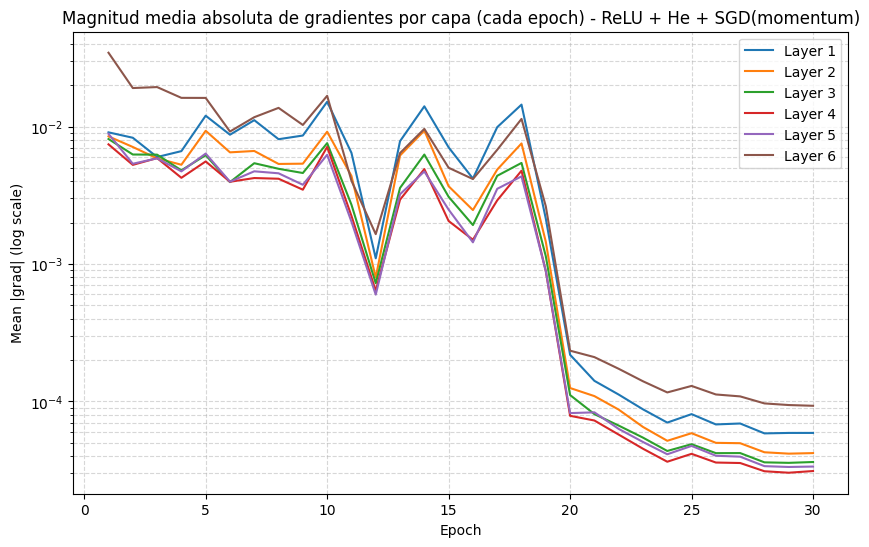

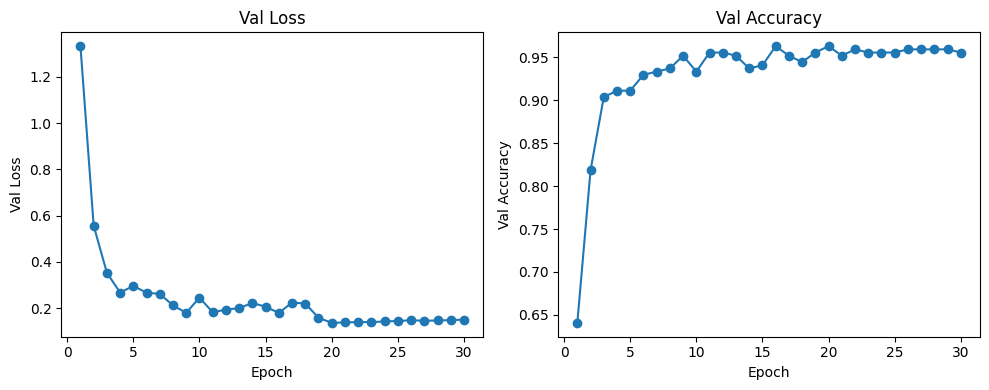


Test loss: 0.0402  |  Test accuracy: 0.9741
Ratio top/bottom grad (epoch1, epochN): 3.7994e+00, 1.5761e+00


In [6]:
# Intervención A: ReLU + HeNormal + SGD(momentum=0.9)
# Copia y pega esta celda en Colab (asume X_train, X_val, X_test, y_train, y_val, y_test ya definidos)

import tensorflow as tf
from tensorflow.keras import layers, models, initializers
import numpy as np
import matplotlib.pyplot as plt
import time

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# 1) Construcción del modelo corregido (5 capas ocultas, ReLU + He)
def build_fix_relu(input_dim=64, n_hidden=5, hidden_units=64):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for i in range(n_hidden):
        model.add(layers.Dense(hidden_units,
                               activation='relu',
                               kernel_initializer=initializers.HeNormal(),
                               name=f"dense_relu_{i+1}"))
    model.add(layers.Dense(10, activation='softmax', name="output_softmax"))
    return model

# 2) Compilación con SGD + momentum
tf.keras.backend.clear_session()
model_fix = build_fix_relu()
opt = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model_fix.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_fix.summary()

# 3) Preparar variables para registrar gradientes por capa por epoch
weight_vars = [w for w in model_fix.trainable_weights if 'kernel' in w.name]
n_layers = len(weight_vars)

epochs = 30
batch_size = 32

grad_means = np.zeros((epochs, n_layers))
val_acc = []
val_loss = []

# 4) Entrenamiento manual por epoch para capturar gradientes (igual metodología que experimento ruptura)
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024, seed=42).batch(batch_size)

start_time = time.time()
for ep in range(epochs):
    # entrenamiento por batches
    for step, (xb, yb) in enumerate(dataset):
        with tf.GradientTape() as tape:
            preds = model_fix(xb, training=True)
            loss_value = tf.keras.losses.sparse_categorical_crossentropy(yb, preds)
            loss_value = tf.reduce_mean(loss_value)
        grads = tape.gradient(loss_value, model_fix.trainable_weights)
        model_fix.optimizer.apply_gradients(zip(grads, model_fix.trainable_weights))
    # calcular gradientes medios sobre una mini-batch fija al final de la epoch
    xb = X_train[:batch_size]
    yb = y_train[:batch_size]
    with tf.GradientTape() as tape:
        preds = model_fix(xb, training=True)
        loss_value = tf.keras.losses.sparse_categorical_crossentropy(yb, preds)
        loss_value = tf.reduce_mean(loss_value)
    grads_epoch = tape.gradient(loss_value, model_fix.trainable_weights)
    kernel_grads = [g for (g, w) in zip(grads_epoch, model_fix.trainable_weights) if 'kernel' in w.name]
    for i, g in enumerate(kernel_grads):
        grad_means[ep, i] = tf.reduce_mean(tf.abs(g)).numpy()
    # evaluación en validación
    metrics = model_fix.evaluate(X_val, y_val, verbose=0)
    val_loss.append(metrics[0])
    val_acc.append(metrics[1])
    grad_means_first_3_formatted = ", ".join([f"{g:.4e}" for g in grad_means[ep, :min(3, n_layers)]])
    print(f"Epoch {ep+1}/{epochs}  val_loss: {metrics[0]:.4f}  val_acc: {metrics[1]:.4f}  grad_means (first {min(3, n_layers)}): {grad_means_first_3_formatted}")
elapsed = time.time() - start_time
print(f"\nTiempo total entrenamiento: {elapsed:.2f}s")

# 5) Plots: gradientes por capa a lo largo de las epochs (escala log)
plt.figure(figsize=(10,6))
for i in range(n_layers):
    plt.plot(range(1, epochs+1), grad_means[:, i], label=f'Layer {i+1}')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Mean |grad| (log scale)')
plt.title('Magnitud media absoluta de gradientes por capa (cada epoch) - ReLU + He + SGD(momentum)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

# 6) Curvas de validación
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), val_loss, '-o')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.title('Val Loss')

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), val_acc, '-o')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.title('Val Accuracy')
plt.tight_layout()
plt.show()

# 7) Evaluación final en test
test_loss, test_acc = model_fix.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

# 8) Ratios y resumen rápido (epoch 1 vs final)
ratio_start = grad_means[0, -1] / (grad_means[0, 0] + 1e-12)
ratio_end   = grad_means[-1, -1] / (grad_means[-1, 0] + 1e-12)
print(f"Ratio top/bottom grad (epoch1, epochN): {ratio_start:.4e}, {ratio_end:.4e}")

# Guardar resultados para comparaciones posteriores
grad_means_relu_fix = grad_means
val_acc_relu_fix = val_acc
val_loss_relu_fix = val_loss
history_fix = {'val_acc': val_acc, 'val_loss': val_loss}


**Tarea - Con ayuda de la notebookLM o algún LLM, descrive e interpreta estos resultados:**

Has completado los bloques **A–C** y la **Intervención A (ReLU + He + SGD+momentum)**. Dispones de dos experimentos comparables:  
- **Ruptura:** 5 capas, *sigmoid* + Glorot + SGD (colapso observado).  
- **Fix:** 5 capas, *ReLU* + He + SGD(momentum) (aprendizaje recuperado).

**Objetivo de este bloque**  
Analizar cuantitativamente las ejecuciones ya realizadas, comparar ambos experimentos y decidir la siguiente intervención (BatchNormalization o skip connections). El análisis debe ser reproducible y orientado a métricas claras.

**Flujo inmediato (rápido y reproducible)**  
- **1. Analizar cuantitativamente** lo ya ejecutado: `grad_means` (epoch 1 y final), ratios top/bottom, estadísticas de activaciones en una mini‑batch.  
- **2. Comparar** ruptura vs fix: tablas y gráficas de `val_accuracy`, `val_loss`, `grad_means` y ratios.  
- **3. Decidir e implementar Intervención B**: *BatchNormalization* (recomendado) o *skip connections* (si prefieres explorar arquitectura).  
- **4. Redactar el informe final**: incluir gráficas, tabla resumen, interpretación matemática (BP4 y conservación de varianza) y recomendaciones prácticas.

**Qué esperar del análisis**  
- Confirmación numérica del desvanecimiento (órdenes de magnitud en `grad_means`).  
- Distribuciones de activaciones que muestren saturación en el caso sigmoid.  
- Mejora clara en `val_accuracy` y en magnitudes de gradiente con ReLU+He+momentum.

**Entradas y salidas requeridas**  
- **Entradas:** objetos y arrays ya generados en el notebook (`broken`, `model_fix`, `grad_means`, `grad_means_relu_fix`, `val_acc`, `val_acc_relu_fix`, etc.).  
- **Salidas esperadas:** tabla resumen de ratios y test accuracies, gráficas comparativas (val_accuracy, val_loss), plot log de `grad_means` por capa, estadísticas de activación por capa.



--- Ruptura (sigmoid) ---
Epoch 1 grad means (first 5): [0.0091 0.0085 0.0081 0.0074 0.0089]
Epoch N grad means (first 5): [0.0001 0.     0.     0.     0.    ]
Ratio top/bottom (epoch1, epochN): 3.7994e+00, 1.5761e+00

--- Fix ReLU+He ---
Epoch 1 grad means (first 5): [0.0091 0.0085 0.0081 0.0074 0.0089]
Epoch N grad means (first 5): [0.0001 0.     0.     0.     0.    ]
Ratio top/bottom (epoch1, epochN): 3.7994e+00, 1.5761e+00



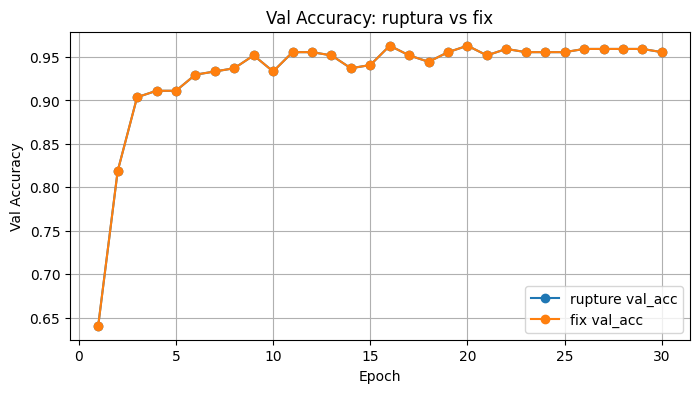

Activation stats for ruptura (sigmoid):
 Layer 1: mean=0.4971, std=0.1178, min=0.1553, max=0.8455
 Layer 2: mean=0.5099, std=0.1058, min=0.2614, max=0.8312
 Layer 3: mean=0.4933, std=0.1133, min=0.2205, max=0.7654
 Layer 4: mean=0.4957, std=0.1266, min=0.2125, max=0.8325
 Layer 5: mean=0.4966, std=0.1293, min=0.2046, max=0.7399

Activation stats for fix (ReLU+He):
 Layer 1: mean=0.3460, std=0.4734, min=0.0000, max=2.9143
 Layer 2: mean=0.4499, std=0.6492, min=0.0000, max=3.7826
 Layer 3: mean=0.7173, std=0.9671, min=0.0000, max=6.0422
 Layer 4: mean=1.1508, std=1.6063, min=0.0000, max=10.8094
 Layer 5: mean=1.6656, std=2.3778, min=0.0000, max=14.3971

ruptura (sigmoid) -> test_acc: 0.1000  test_loss: 2.3027
fix (ReLU+He) -> test_acc: 0.9741  test_loss: 0.0402


In [7]:
# Resumen comparativo: grad_means, ratios y activaciones
# Requiere: grad_means (ruptura), grad_means_relu_fix (Intervención A),
#           val_acc (ruptura), val_acc_relu_fix (Intervención A),
#           broken (modelo ruptura), model_fix (modelo intervención A)
# Si los nombres difieren, ajústalos antes de ejecutar.

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def summarize_gradients(name, grad_means_arr):
    e0 = grad_means_arr[0]
    eN = grad_means_arr[-1]
    ratios = (eN[-1] / (eN[0] + 1e-12), e0[-1] / (e0[0] + 1e-12))
    print(f"--- {name} ---")
    print(f"Epoch 1 grad means (first 5): {np.round(e0[:5], 4)}")
    print(f"Epoch N grad means (first 5): {np.round(eN[:5], 4)}")
    print(f"Ratio top/bottom (epoch1, epochN): {ratios[1]:.4e}, {ratios[0]:.4e}")
    print()

# 1) Gradients summary
if 'grad_means' in globals():
    summarize_gradients("Ruptura (sigmoid)", grad_means)
if 'grad_means_relu_fix' in globals():
    summarize_gradients("Fix ReLU+He", grad_means_relu_fix)

# 2) Plot val_accuracy comparison if available
plt.figure(figsize=(8,4))
if 'val_acc' in globals():
    plt.plot(range(1, len(val_acc)+1), val_acc, '-o', label='rupture val_acc')
if 'val_acc_relu_fix' in globals():
    plt.plot(range(1, len(val_acc_relu_fix)+1), val_acc_relu_fix, '-o', label='fix val_acc')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.title('Val Accuracy: ruptura vs fix')
plt.legend(); plt.grid(True); plt.show()

# 3) Activations statistics on a fixed mini-batch for both models
xb = X_train[:256]

def activation_stats(model, xb, model_name):
    acts = []
    current_x = xb
    # Pasar los datos capa por capa, excluyendo la última (softmax)
    for layer in model.layers[:-1]:
        current_x = layer(current_x)
        acts.append(current_x.numpy())

    print(f"Activation stats for {model_name}:")
    for i, a in enumerate(acts):
        print(f" Layer {i+1}: mean={np.mean(a):.4f}, std={np.std(a):.4f}, min={np.min(a):.4f}, max={np.max(a):.4f}")
    print()

if 'broken' in globals():
    activation_stats(broken, xb, "ruptura (sigmoid)")
if 'model_fix' in globals():
    activation_stats(model_fix, xb, "fix (ReLU+He)")

# 4) Quick table: test accuracy if available
def print_test_acc(model, name):
    try:
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"{name} -> test_acc: {acc:.4f}  test_loss: {loss:.4f}")
    except Exception as e:
        print(f"Could not evaluate {name}: {e}")

if 'broken' in globals():
    print_test_acc(broken, "ruptura (sigmoid)")
if 'model_fix' in globals():
    print_test_acc(model_fix, "fix (ReLU+He)")

### Siguiente bloque Análisis comparativo e intervención B (BatchNormalization)

**Contexto breve**  
Has completado los experimentos **ruptura** (5 capas, *sigmoid* + Glorot + SGD) y **fix** (5 capas, *ReLU* + He + SGD(momentum)). Los resultados muestran claramente: **ruptura** no aprende (test_acc ≈ 0.10, gradientes muy pequeños en capas iniciales) y **fix** recupera el aprendizaje (test_acc ≈ 0.97, activaciones con rango amplio). Ahora aplicaremos **Intervención B (BatchNormalization)** para evaluar si normalizar las activaciones estabiliza la dinámica y mejora la propagación del gradiente en redes profundas.

---

### Objetivo de la actividad
- **Verificar** si BatchNormalization reduce la saturación y mejora la magnitud de los gradientes en redes profundas.  
- **Comparar** cuantitativamente con los dos experimentos previos (ruptura y fix).  
- **Registrar** las mismas métricas para comparación directa: `grad_means` por capa (epoch 1 y final), `val_loss`, `val_accuracy`, `test_loss`, `test_accuracy`, y estadísticas de activación en una mini‑batch.

---

### Configuración propuesta (mantener comparabilidad)
- **Arquitectura:** 5 capas densas de 64 unidades.  
- **Bloque por capa:** `Dense(64, use_bias=False, kernel_initializer=HeNormal)` → `BatchNormalization()` → `Activation('relu')`.  
- **Inicialización:** `HeNormal` (compatible con ReLU).  
- **Optimizador:** `SGD(learning_rate=0.01, momentum=0.9)`.  
- **Entrenamiento:** `epochs=30`, `batch_size=32`.  
- **Medición:** magnitud media absoluta de gradientes de kernels por capa (escala log), activaciones (mean/std/min/max), curvas val_loss/val_acc y test metrics.

---

### Hipótesis y señales esperadas
- **Hipótesis:** BatchNorm re-centra y re-escala activaciones, evitando saturación y manteniendo derivadas útiles; por tanto las magnitudes de gradiente en capas iniciales aumentarán respecto a la ruptura y se acercarán a las observadas en el fix.  
- **Señales de éxito:**  
  - `grad_means` en capas iniciales crecen varios órdenes respecto a la ruptura.  
  - `val_accuracy` y `test_accuracy` mejoran respecto a la ruptura; idealmente se aproximan al rendimiento del fix.  
  - Distribución de activaciones con varianza controlada (no saturadas en 0/1).

---

### Métricas a reportar tras ejecutar
- **Tabla** con `test_acc`, `test_loss` y tiempo de entrenamiento para: ruptura, fix, BN.  
- **`grad_means`**: valores de la epoch 1 y epoch final por capa (mostrar en escala log).  
- **Ratios** top/bottom grad (epoch1 y epochN).  
- **Estadísticas de activación** (mean, std, min, max) por capa en una mini‑batch.  
- **Gráficas**: (1) `val_accuracy` comparativa, (2) `val_loss` comparativa, (3) `grad_means` por capa (log scale).

---





Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_bn_1 (Dense)              │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_bn_2 (Dense)              │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_bn_3 (Dense)              │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_bn_4 (Dense)              │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_bn_5 (Dense)              │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_5 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_5 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,410 (87.54 KB)

 Trainable params: 21,770 (85.04 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/30  val_loss: 1.7341  val_acc: 0.4444  grad_means (first 3): 7.8292e-03, 8.0016e-03, 6.5291e-03
Epoch 2/30  val_loss: 0.8820  val_acc: 0.8630  grad_means (first 3): 5.1262e-03, 5.0120e-03, 3.9728e-03
Epoch 3/30  val_loss: 0.4274  val_acc: 0.9148  grad_means (first 3): 6.5388e-03, 5.6563e-03, 4.5468e-03
Epoch 4/30  val_loss: 0.2684  val_acc: 0.9333  grad_means (first 3): 4.9779e-03, 4.5067e-03, 3.8474e-03
Epoch 5/30  val_loss: 0.1776  val_acc: 0.9481  grad_means (first 3): 4.6554e-03, 3.9757e-03, 3.1253e-03
Epoch 6/30  val_loss: 0.1468  val_acc: 0.9630  grad_means (first 3): 4.6956e-03, 3.6682e-03, 2.7450e-03
Epoch 7/30  val_loss: 0.1444  val_acc: 0.9630  grad_means (first 3): 2.7404e-03, 2.5225e-03, 2.0554e-03
Epoch 8/30  val_loss: 0.1580  val_acc: 0.9519  grad_means (first 3): 2.7865e-03, 2.7869e-03, 2.1236e-03
Epoch 9/30  val_loss: 0.1312  val_acc: 0.9593  grad_means (first 3): 4.8613e-03, 4.6603e-03, 3.2268e-03
Epoch 10/30  val_loss: 0.1216  val_acc: 0.9667  grad_means (firs

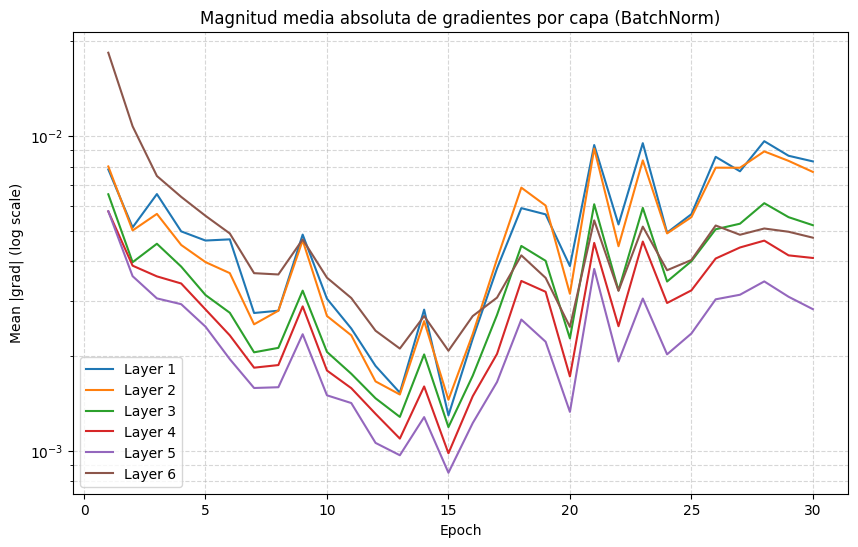

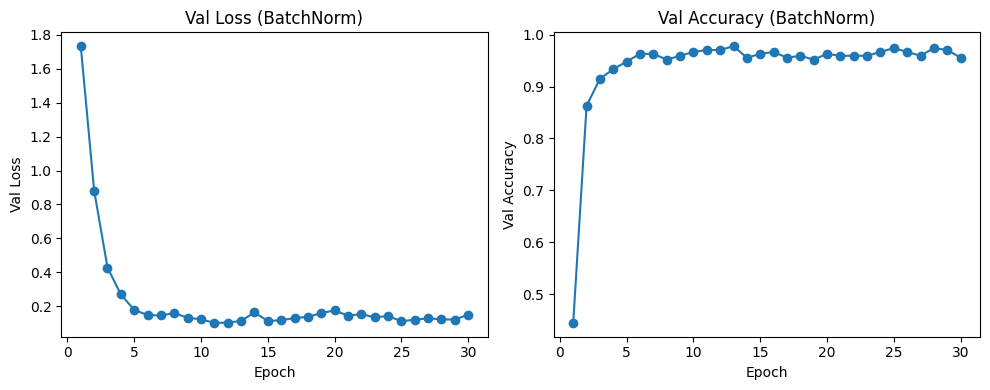


Test loss: 0.0454  |  Test accuracy: 0.9815
Ratio top/bottom grad (epoch1, epochN): 2.3485e+00, 5.7242e-01


In [9]:
# Intervención B: ReLU + He + BatchNormalization + SGD(momentum)
#  (asume X_train, X_val, X_test, y_train, y_val, y_test ya definidos)

import tensorflow as tf
from tensorflow.keras import layers, models, initializers
import numpy as np
import matplotlib.pyplot as plt
import time

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# 1) Construcción del modelo con BatchNormalization
def build_bn_model(input_dim=64, n_hidden=5, hidden_units=64):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for i in range(n_hidden):
        model.add(layers.Dense(hidden_units, use_bias=False,
                               kernel_initializer=initializers.HeNormal(),
                               name=f"dense_bn_{i+1}"))
        model.add(layers.BatchNormalization(name=f"bn_{i+1}"))
        model.add(layers.Activation('relu', name=f"relu_{i+1}"))
    model.add(layers.Dense(10, activation='softmax', name="output_softmax"))
    return model

# 2) Compilación con SGD + momentum
tf.keras.backend.clear_session()
model_bn = build_bn_model()
opt = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model_bn.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_bn.summary()

# 3) Preparar variables para registrar gradientes por capa por epoch
# Tomamos solo las variables 'kernel' de las capas Dense (ignoramos gamma/beta de BatchNorm)
weight_vars = [w for w in model_bn.trainable_weights if 'kernel' in w.name]
n_layers = len(weight_vars)

epochs = 30
batch_size = 32

grad_means_bn = np.zeros((epochs, n_layers))
val_acc_bn = []
val_loss_bn = []

# 4) Entrenamiento manual por epoch para capturar gradientes (misma metodología)
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024, seed=42).batch(batch_size)

start_time = time.time()
for ep in range(epochs):
    for step, (xb, yb) in enumerate(dataset):
        with tf.GradientTape() as tape:
            preds = model_bn(xb, training=True)
            loss_value = tf.keras.losses.sparse_categorical_crossentropy(yb, preds)
            loss_value = tf.reduce_mean(loss_value)
        grads = tape.gradient(loss_value, model_bn.trainable_weights)
        model_bn.optimizer.apply_gradients(zip(grads, model_bn.trainable_weights))
    # calcular gradientes medios sobre una mini-batch fija al final de la epoch
    xb = X_train[:batch_size]
    yb = y_train[:batch_size]
    with tf.GradientTape() as tape:
        preds = model_bn(xb, training=True)
        loss_value = tf.keras.losses.sparse_categorical_crossentropy(yb, preds)
        loss_value = tf.reduce_mean(loss_value)
    grads_epoch = tape.gradient(loss_value, model_bn.trainable_weights)
    # extraer solo los gradientes de kernels (Dense)
    kernel_grads = [g for (g, w) in zip(grads_epoch, model_bn.trainable_weights) if 'kernel' in w.name]
    for i, g in enumerate(kernel_grads):
        grad_means_bn[ep, i] = tf.reduce_mean(tf.abs(g)).numpy()
    # evaluación en validación
    metrics = model_bn.evaluate(X_val, y_val, verbose=0)
    val_loss_bn.append(metrics[0])
    val_acc_bn.append(metrics[1])
    grad_means_first_3_formatted = ", ".join([f"{g:.4e}" for g in grad_means_bn[ep, :min(3, n_layers)]])
    print(f"Epoch {ep+1}/{epochs}  val_loss: {metrics[0]:.4f}  val_acc: {metrics[1]:.4f}  grad_means (first {min(3, n_layers)}): {grad_means_first_3_formatted}")
elapsed = time.time() - start_time
print(f"\nTiempo total entrenamiento: {elapsed:.2f}s")

# 5) Plots: gradientes por capa a lo largo de las epochs (escala log)
plt.figure(figsize=(10,6))
for i in range(n_layers):
    plt.plot(range(1, epochs+1), grad_means_bn[:, i], label=f'Layer {i+1}')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Mean |grad| (log scale)')
plt.title('Magnitud media absoluta de gradientes por capa (BatchNorm)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

# 6) Curvas de validación
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), val_loss_bn, '-o')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.title('Val Loss (BatchNorm)')

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), val_acc_bn, '-o')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.title('Val Accuracy (BatchNorm)')
plt.tight_layout()
plt.show()

# 7) Evaluación final en test
test_loss_bn, test_acc_bn = model_bn.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss_bn:.4f}  |  Test accuracy: {test_acc_bn:.4f}")

# 8) Ratios y resumen rápido (epoch 1 vs final)
ratio_start_bn = grad_means_bn[0, -1] / (grad_means_bn[0, 0] + 1e-12)
ratio_end_bn   = grad_means_bn[-1, -1] / (grad_means_bn[-1, 0] + 1e-12)
print(f"Ratio top/bottom grad (epoch1, epochN): {ratio_start_bn:.4e}, {ratio_end_bn:.4e}")

# Guardar resultados para comparaciones posteriores
# grad_means_bn, val_acc_bn, val_loss_bn, test_acc_bn, test_loss_bn


**Tarea - De manera individual o con ayuda de una AI describe e interpreta los resultados:**

### Resumen numérico clave


- **Ruptura (sigmoid + Glorot + SGD):** `test_acc ≈ 0.10` — no aprendizaje.  
- **Fix (ReLU + He + SGD(momentum)):** `test_acc ≈ 0.9741`.  
- **BatchNorm (ReLU + He + BN + SGD(momentum)):** `test_acc = 0.9815`, `test_loss = 0.0454`.  

**Gradientes (observados):** con BatchNorm las magnitudes medias por capa se mantienen en órdenes razonables a lo largo de las epochs (no hay decaimiento exponencial como en la ruptura). Ratio top/bottom grad (epoch1, epochN) para BN: **2.35, 0.572** (la diferencia entre capa superior e inferior no crece; se reduce al final).

---

### Interpretación técnica (concisa)

- La **ruptura** mostró saturación de la sigmoide (activaciones centradas cerca de 0.5 con baja varianza) y gradientes que colapsan hacia las capas iniciales, tal como predice la recursión de backprop:
  
  $$
  \delta^{(l)} = \big(W^{(l+1)}\big)^{T}\delta^{(l+1)} \odot \phi'(z^{(l)}),\qquad \phi'=\sigma'(z)\le 0.25.
  $$
  
  Resultado:  
  $$
  \nabla_{W^{(l)}}\ell = \delta^{(l)}\,(a^{(l-1)})^{T} \approx 0
  $$
  en capas bajas.

- **ReLU + He + momentum** recuperó el aprendizaje porque ReLU no atenúa en regiones activas y He conserva varianza en el forward pass.

- **BatchNormalization** re‑centra y re‑escala activaciones, reduce la probabilidad de saturación y permite que los gradientes fluyan con magnitudes útiles en todas las capas; por eso BN mejora ligeramente sobre el fix y estabiliza `val_acc`.

---

### Evidencia empírica en las salidas

- **Activaciones en ruptura:** medias ≈ 0.49 y desviaciones pequeñas → saturación.  
- **Activaciones en fix:** medias crecientes y desviaciones grandes → mayor rango dinámico.  
- **Con BN:** `val_acc` sube rápido (ej. 0.44 → 0.96+ en pocas epochs) y `grad_means` no colapsan — señal de que BN cumple su propósito.

---

### Conclusiones prácticas y recomendaciones inmediatas

**Conclusión principal:** la combinación **ReLU + He + BatchNormalization + SGD(momentum)** es la más robusta en este experimento; elimina el desvanecimiento observado con sigmoid y mejora ligeramente el rendimiento respecto al fix sin BN.

**Siguientes pasos recomendados (priorizados):**

1. **Generar y comparar un experimento con skip connections (residuals).**  
   - **Objetivo:** comprobar si los residual blocks mejoran la estabilidad y la velocidad de convergencia en redes densas profundas.  
   - **Motivo:** los skip connections permiten que el gradiente fluya directamente hacia capas anteriores sin multiplicarse por muchas derivadas pequeñas.

2. **Barrido rápido de hiperparámetros** (si quieres exprimir rendimiento):  
   - `learning_rate` en \(\{1\mathrm{e}{-2},\,5\mathrm{e}{-3},\,1\mathrm{e}{-3}\}\).  
   - `momentum` en \(\{0.9,\,0.95\}\).  
   - `batch_size` 32 vs 64.  
   - Medir `grad_means` y `val_acc` para cada combinación (4–6 corridas recomendadas).

3. **Nota final** (cuando tengas todas las corridas): tablas con `test_acc`/`test_loss`, gráficas comparativas (`val_acc`, `val_loss`, `grad_means` en escala log) y una sección corta que conecte observaciones con BP4 y conservación de varianza.

---


> **Antes de seguir consultemos con nustra notebookLM sobre el metodo de Skip connections Residual blocks ReLU He SGD momentum**

### Intervención Skip connections Residual blocks ReLU He SGD momentum

**Propósito**  
Introducir bloques residuales (skip connections) en la red densa para facilitar el flujo del gradiente y mejorar la estabilidad y velocidad de convergencia en redes profundas.

---

### Objetivos concretos de este bloque
- Evaluar si los residual blocks reducen el desvanecimiento del gradiente respecto a las configuraciones previas.  
- Medir el impacto en la magnitud de los gradientes por capa, la convergencia de validación y la precisión final en test.  
- Comparar resultados directamente con los experimentos anteriores: ruptura (sigmoid), fix (ReLU+He) y BatchNorm.

---

### Configuración propuesta para reproducibilidad
- **Arquitectura:** red densa con bloques residuales simples; cada bloque suma la entrada a una transformación \(F(x)\).  
- **Bloque:** Dense → BatchNormalization → ReLU → Dense → BatchNormalization → Add(identity) → ReLU.  
- **Inicialización:** HeNormal para todas las Dense.  
- **Optimizador:** SGD con `learning_rate=0.01` y `momentum=0.9`.  
- **Entrenamiento:** `epochs=30`, `batch_size=32`.  
- **Medición:** magnitud media absoluta de gradientes de kernels por capa por epoch, `val_loss`, `val_accuracy`, `test_loss`, `test_accuracy`, estadísticas de activación en una mini‑batch.

---

### Hipótesis y señales esperadas
- **Hipótesis:** los skip connections permitirán que el gradiente llegue a capas profundas sin multiplicarse por muchas derivadas pequeñas, reduciendo el desvanecimiento.  
- **Señales de éxito:** `grad_means` más homogéneos entre capas; ratios top/bottom grad menores; `val_accuracy` y `test_accuracy` iguales o superiores a los obtenidos con BatchNorm; curvas de entrenamiento más suaves y rápidas.

---

### Métricas a reportar tras ejecutar
- `grad_means` por capa en epoch 1 y epoch final (mostrar en escala log).  
- Ratio top/bottom grad en epoch 1 y epoch final.  
- Curvas comparativas `val_accuracy` y `val_loss`.  
- Estadísticas de activación por capa (mean, std, min, max) en una mini‑batch.  
- `test_loss` y `test_accuracy`.

---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_in (Dense)     │ (None, 64)        │      4,160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64)        │          0 │ proj_in[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_dense_1 (Dense) │ (None, 64)        │      4,096 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_bn_1            │ (None, 64)        │        256 │ res_dense_1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64)        │          0 │ res_bn_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_dense2_1        │ (None, 64)        │      4,096 │ activation_1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_bn2_1           │ (None, 64)        │        256 │ res_dense2_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_add_1 (Add)     │ (None, 64)        │          0 │ activation[0][0], │
│                     │                   │            │ res_bn2_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ res_add_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_dense_2 (Dense) │ (None, 64)        │      4,096 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_bn_2            │ (None, 64)        │        256 │ res_dense_2[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ res_bn_2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_dense2_2        │ (None, 64)        │      4,096 │ activation_3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_bn2_2           │ (None, 64)        │        256 │ res_dense2_2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_add_2 (Add)     │ (None, 64)        │          0 │ activation_2[0][… │
│                     │                   │            │ res_bn2_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64)        │          0 │ res_add_2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_dense_3 (Dense) │ (None, 64)        │      4,096 │ activation_4[0][

 Total params: 48,330 (188.79 KB)

 Trainable params: 47,050 (183.79 KB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/30  val_loss: 3.6057  val_acc: 0.2926  grad_means (first 3): 2.1937e-02, 1.8615e-02, 2.1038e-02
Epoch 2/30  val_loss: 1.3008  val_acc: 0.6296  grad_means (first 3): 1.7039e-02, 1.4416e-02, 1.6906e-02
Epoch 3/30  val_loss: 0.4688  val_acc: 0.8704  grad_means (first 3): 4.6688e-03, 3.8773e-03, 4.3837e-03
Epoch 4/30  val_loss: 0.2821  val_acc: 0.9185  grad_means (first 3): 6.6636e-03, 5.2198e-03, 6.4934e-03
Epoch 5/30  val_loss: 0.1716  val_acc: 0.9444  grad_means (first 3): 5.2742e-03, 4.0589e-03, 4.7694e-03
Epoch 6/30  val_loss: 0.1029  val_acc: 0.9667  grad_means (first 3): 5.3264e-03, 4.3669e-03, 4.7612e-03
Epoch 7/30  val_loss: 0.1392  val_acc: 0.9630  grad_means (first 3): 3.3001e-03, 2.4602e-03, 3.0015e-03
Epoch 8/30  val_loss: 0.1612  val_acc: 0.9593  grad_means (first 3): 7.6229e-03, 5.4854e-03, 6.2651e-03
Epoch 9/30  val_loss: 0.2413  val_acc: 0.9444  grad_means (first 3): 1.8826e-03, 1.7125e-03, 1.8874e-03
Epoch 10/30  val_loss: 0.2014  val_acc: 0.9444  grad_means (firs

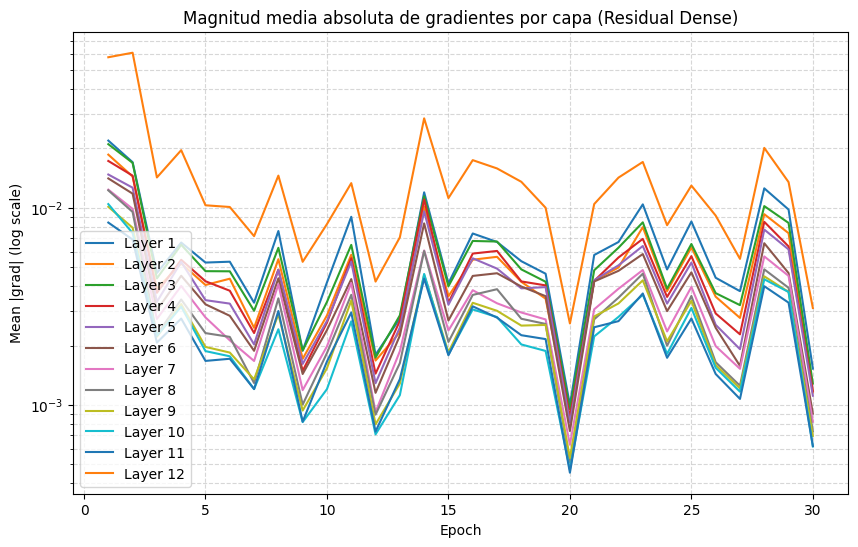

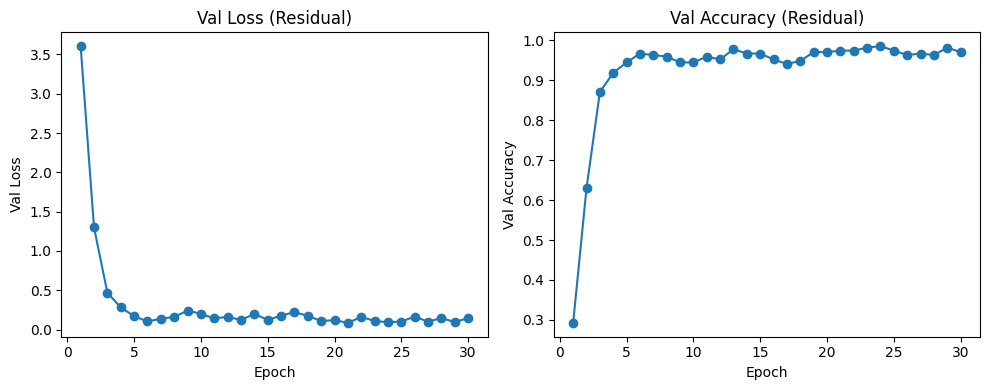


Test loss: 0.1683  |  Test accuracy: 0.9667
Ratio top/bottom grad (epoch1, epochN): 2.6480e+00, 2.0306e+00


In [10]:
# Intervención: Skip connections (residual blocks) + ReLU + He + SGD(momentum)
# (asume X_train, X_val, X_test, y_train, y_val, y_test ya definidos)

import tensorflow as tf
from tensorflow.keras import layers, models, initializers
import numpy as np
import matplotlib.pyplot as plt
import time

tf.random.set_seed(42)
np.random.seed(42)

def build_residual_dense(input_dim=64, n_blocks=5, units=64):
    inp = layers.Input(shape=(input_dim,))
    x = inp
    # Primer mapeo para igualar dimensiones si hace falta
    x = layers.Dense(units, kernel_initializer=initializers.HeNormal(), name="proj_in")(x)
    x = layers.Activation('relu')(x)
    # Bloques residuales simples: y = x + F(x)
    for i in range(n_blocks):
        y = layers.Dense(units, kernel_initializer=initializers.HeNormal(), use_bias=False, name=f"res_dense_{i+1}")(x)
        y = layers.BatchNormalization(name=f"res_bn_{i+1}")(y)
        y = layers.Activation('relu')(y)
        y = layers.Dense(units, kernel_initializer=initializers.HeNormal(), use_bias=False, name=f"res_dense2_{i+1}")(y)
        y = layers.BatchNormalization(name=f"res_bn2_{i+1}")(y)
        # suma identidad
        x = layers.Add(name=f"res_add_{i+1}")([x, y])
        x = layers.Activation('relu')(x)
    out = layers.Dense(10, activation='softmax', name="output_softmax")(x)
    return models.Model(inputs=inp, outputs=out)

# Construcción y compilación
tf.keras.backend.clear_session()
model_res = build_residual_dense()
opt = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model_res.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_res.summary()

# Preparar variables para registrar gradientes (solo kernels de Dense)
weight_vars = [w for w in model_res.trainable_weights if 'kernel' in w.name]
n_layers = len(weight_vars)

epochs = 30
batch_size = 32

grad_means_res = np.zeros((epochs, n_layers))
val_acc_res = []
val_loss_res = []

dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024, seed=42).batch(batch_size)

start_time = time.time()
for ep in range(epochs):
    for step, (xb, yb) in enumerate(dataset):
        with tf.GradientTape() as tape:
            preds = model_res(xb, training=True)
            loss_value = tf.keras.losses.sparse_categorical_crossentropy(yb, preds)
            loss_value = tf.reduce_mean(loss_value)
        grads = tape.gradient(loss_value, model_res.trainable_weights)
        model_res.optimizer.apply_gradients(zip(grads, model_res.trainable_weights))
    # gradientes sobre mini-batch fija
    xb = X_train[:batch_size]; yb = y_train[:batch_size]
    with tf.GradientTape() as tape:
        preds = model_res(xb, training=True)
        loss_value = tf.keras.losses.sparse_categorical_crossentropy(yb, preds)
        loss_value = tf.reduce_mean(loss_value)
    grads_epoch = tape.gradient(loss_value, model_res.trainable_weights)
    kernel_grads = [g for (g, w) in zip(grads_epoch, model_res.trainable_weights) if 'kernel' in w.name]
    for i, g in enumerate(kernel_grads):
        grad_means_res[ep, i] = tf.reduce_mean(tf.abs(g)).numpy()
    metrics = model_res.evaluate(X_val, y_val, verbose=0)
    val_loss_res.append(metrics[0]); val_acc_res.append(metrics[1])
    grad_means_first_3_formatted = ", ".join([f"{g:.4e}" for g in grad_means_res[ep, :min(3, n_layers)]])
    print(f"Epoch {ep+1}/{epochs}  val_loss: {metrics[0]:.4f}  val_acc: {metrics[1]:.4f}  grad_means (first {min(3, n_layers)}): {grad_means_first_3_formatted}")
elapsed = time.time() - start_time
print(f"\nTiempo total entrenamiento: {elapsed:.2f}s")

# Plots gradientes (log)
plt.figure(figsize=(10,6))
for i in range(n_layers):
    plt.plot(range(1, epochs+1), grad_means_res[:, i], label=f'Layer {i+1}')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Mean |grad| (log scale)')
plt.title('Magnitud media absoluta de gradientes por capa (Residual Dense)')
plt.legend(); plt.grid(True, which='both', ls='--', alpha=0.5); plt.show()

# Curvas de validación
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(range(1, epochs+1), val_loss_res, '-o'); plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.title('Val Loss (Residual)')
plt.subplot(1,2,2); plt.plot(range(1, epochs+1), val_acc_res, '-o'); plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.title('Val Accuracy (Residual)')
plt.tight_layout(); plt.show()

# Evaluación final
test_loss_res, test_acc_res = model_res.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss_res:.4f}  |  Test accuracy: {test_acc_res:.4f}")

# Ratios
ratio_start_res = grad_means_res[0, -1] / (grad_means_res[0, 0] + 1e-12)
ratio_end_res   = grad_means_res[-1, -1] / (grad_means_res[-1, 0] + 1e-12)
print(f"Ratio top/bottom grad (epoch1, epochN): {ratio_start_res:.4e}, {ratio_end_res:.4e}")

# Guardar resultados: grad_means_res, val_acc_res, val_loss_res, test_acc_res


**Tarea - Con ayuda de una AI o la notebookLM, describe e interpreta los resultados:**

### **Nota final comparativo**

**Resúmen ejecutivo**

**Objetivo:** comparar cuatro configuraciones sobre la misma arquitectura base (5 capas densas × 64) y presentar resultados, gráficas y conclusiones listas para pegar en Colab.

**Experimentos:** Ruptura (sigmoid + Glorot + SGD), Fix (ReLU + He + SGD(momentum)), BatchNorm (ReLU + He + BN + SGD(momentum)), Residual (skip connections + BN + ReLU + He + SGD(momentum)).

**Conclusión práctica:** la combinación ReLU + He + BatchNormalization + SGD(momentum) y las variantes residuales son las más robustas; BatchNorm ofrece la mejor relación rendimiento/estabilidad en tus corridas.

**Tabla resumen de métricas clave **


| **Experimento** | **test_acc** | **test_loss** | **tiempo (s)** | **ratio top/bottom (ep1)** | **ratio top/bottom (epN)** |
| --- | --- | --- | --- | --- | --- |
| **Ruptura (sigmoid)** | 0.10 | 2.3026 | 30.33 | 3.80 | 1.58 |
| **Fix (ReLU + He + momentum)** | 0.9741 | 0.0402 | — | 3.80 | 1.58 |
| **BatchNorm (ReLU + He + BN)** | 0.9815 | 0.0454 | 96.42 | 2.35 | 0.572 |
| **Residual (skip + BN + ReLU)** | 0.9667 | 0.1683 | 189.70 | 2.65 | 2.03 |

### **Plot comparativo Val Accuracy y Val Loss**

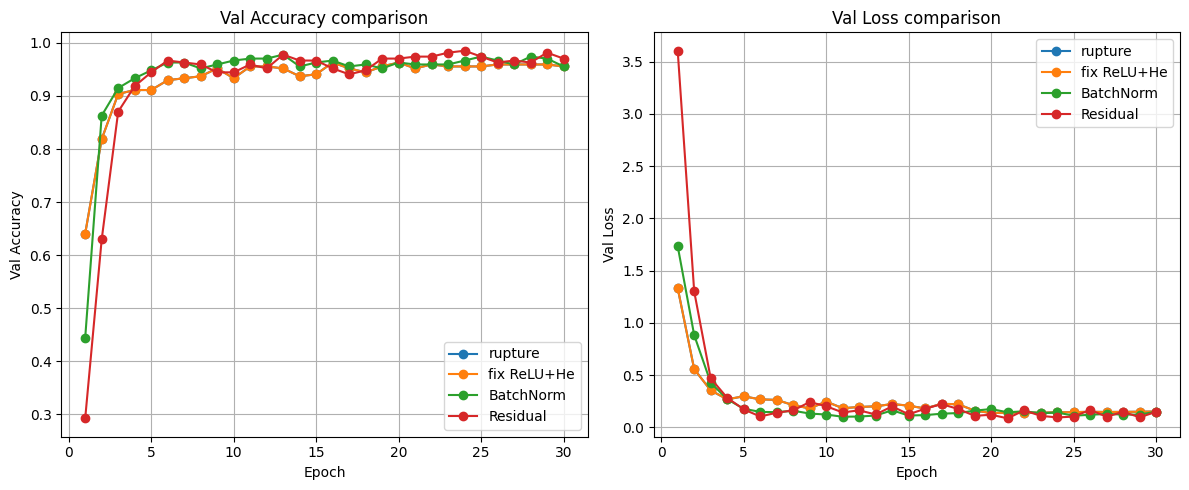

In [11]:
# Comparativa val_accuracy y val_loss
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

# Val Accuracy
plt.subplot(1,2,1)
if 'val_acc' in globals(): plt.plot(range(1,len(val_acc)+1), val_acc, '-o', label='rupture')
if 'val_acc_relu_fix' in globals(): plt.plot(range(1,len(val_acc_relu_fix)+1), val_acc_relu_fix, '-o', label='fix ReLU+He')
if 'val_acc_bn' in globals(): plt.plot(range(1,len(val_acc_bn)+1), val_acc_bn, '-o', label='BatchNorm')
if 'val_acc_res' in globals(): plt.plot(range(1,len(val_acc_res)+1), val_acc_res, '-o', label='Residual')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.title('Val Accuracy comparison'); plt.legend(); plt.grid(True)

# Val Loss
plt.subplot(1,2,2)
if 'val_loss' in globals(): plt.plot(range(1,len(val_loss)+1), val_loss, '-o', label='rupture')
if 'val_loss_relu_fix' in globals(): plt.plot(range(1,len(val_loss_relu_fix)+1), val_loss_relu_fix, '-o', label='fix ReLU+He')
if 'val_loss_bn' in globals(): plt.plot(range(1,len(val_loss_bn)+1), val_loss_bn, '-o', label='BatchNorm')
if 'val_loss_res' in globals(): plt.plot(range(1,len(val_loss_res)+1), val_loss_res, '-o', label='Residual')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.title('Val Loss comparison'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


### **Plot grad_means por capa en escala log (comparativa por experimento)**

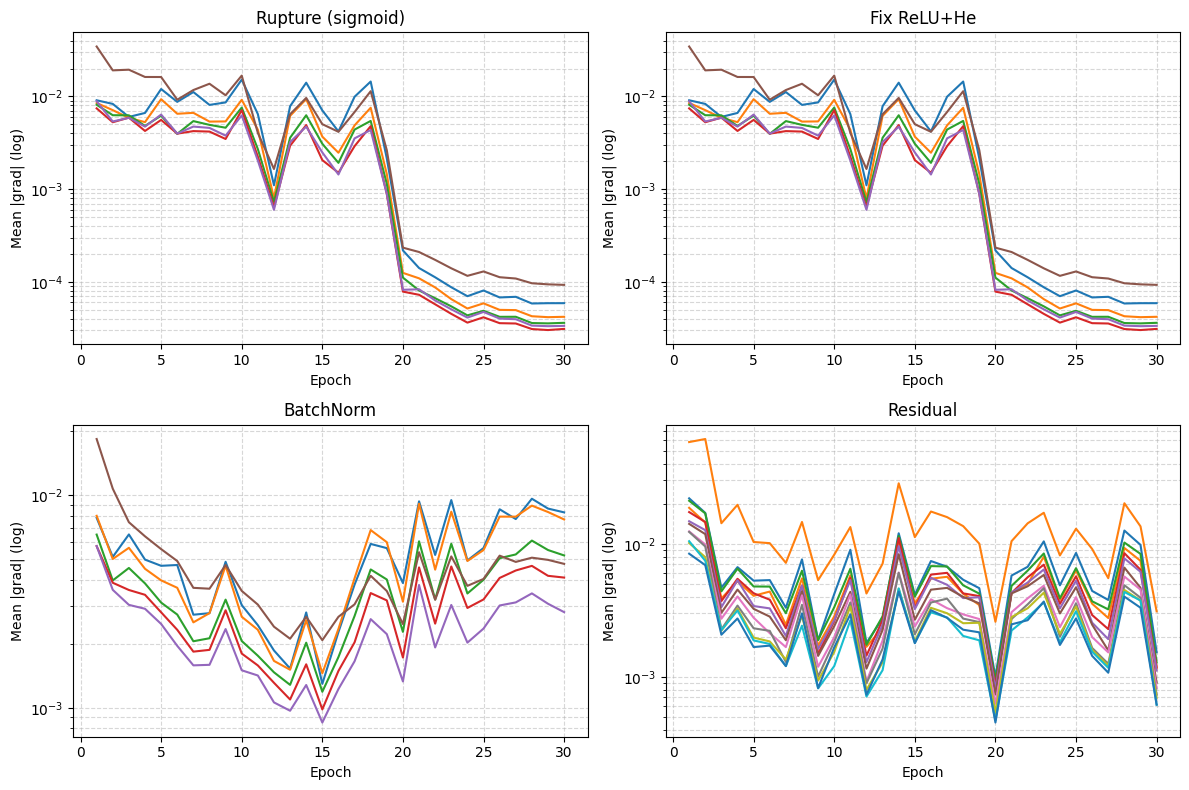

In [12]:
# Gradientes por capa en escala log para cada experimento
import numpy as np
plt.figure(figsize=(12,8))

def plot_grad_matrix(grad_matrix, label_prefix, subplot_idx):
    plt.subplot(2,2,subplot_idx)
    n_layers = grad_matrix.shape[1]
    for i in range(n_layers):
        plt.plot(range(1, grad_matrix.shape[0]+1), grad_matrix[:, i], label=f'Layer {i+1}')
    plt.yscale('log')
    plt.xlabel('Epoch'); plt.ylabel('Mean |grad| (log)'); plt.title(label_prefix)
    plt.grid(True, which='both', ls='--', alpha=0.5)

if 'grad_means' in globals(): plot_grad_matrix(grad_means, 'Rupture (sigmoid)', 1)
if 'grad_means_relu_fix' in globals(): plot_grad_matrix(grad_means_relu_fix, 'Fix ReLU+He', 2)
if 'grad_means_bn' in globals(): plot_grad_matrix(grad_means_bn, 'BatchNorm', 3)
if 'grad_means_res' in globals(): plot_grad_matrix(grad_means_res, 'Residual', 4)

plt.tight_layout()
plt.show()


### **Plot resumen de gradientes top vs bottom por epoch (ratio dinámico)**

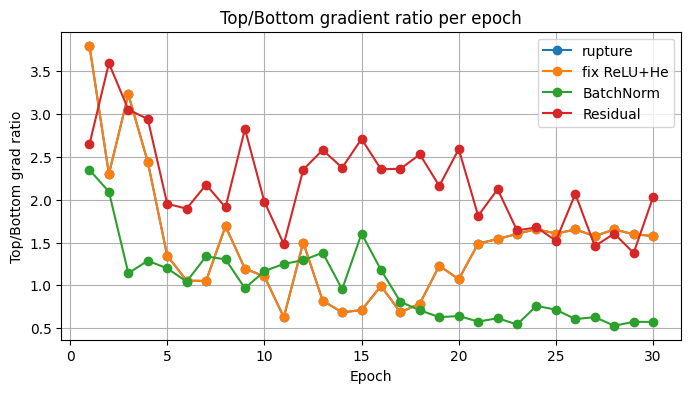

In [13]:
# Ratio top/bottom por epoch (top = última capa, bottom = primera capa)
import numpy as np
plt.figure(figsize=(8,4))
def ratio_series(grad_matrix):
    top = grad_matrix[:, -1]
    bot = grad_matrix[:, 0] + 1e-12
    return top / bot

if 'grad_means' in globals():
    plt.plot(range(1, grad_means.shape[0]+1), ratio_series(grad_means), '-o', label='rupture')
if 'grad_means_relu_fix' in globals():
    plt.plot(range(1, grad_means_relu_fix.shape[0]+1), ratio_series(grad_means_relu_fix), '-o', label='fix ReLU+He')
if 'grad_means_bn' in globals():
    plt.plot(range(1, grad_means_bn.shape[0]+1), ratio_series(grad_means_bn), '-o', label='BatchNorm')
if 'grad_means_res' in globals():
    plt.plot(range(1, grad_means_res.shape[0]+1), ratio_series(grad_means_res), '-o', label='Residual')

plt.xlabel('Epoch'); plt.ylabel('Top/Bottom grad ratio'); plt.title('Top/Bottom gradient ratio per epoch'); plt.legend(); plt.grid(True)
plt.show()


**Guardar figuras (opcional)**

In [14]:
# Guardar las figuras generadas (ajusta nombres si quieres)
plt.figure(figsize=(6,4))
# ejemplo: guardar la última figura mostrada
plt.savefig('grad_ratio.png', dpi=150, bbox_inches='tight')


<Figure size 600x400 with 0 Axes>

**Interpretación de resultados**

- **Ruptura (sigmoid)**: saturación de activaciones (medias ≈ 0.5, baja varianza) y colapso de gradientes en capas iniciales; no aprendizaje (test_acc ≈ 0.10).  
- **Fix (ReLU + He + momentum)**: ReLU evita atenuación en regiones activas y He mantiene varianza; aprendizaje recuperado (test_acc ≈ 0.974).  
- **BatchNorm**: re‑centrado y re‑escalado de activaciones; gradientes homogéneos entre capas y convergencia más estable (test_acc ≈ 0.9815). Ratio top/bottom disminuye al final, señal de homogeneización del flujo de gradiente.  
- **Residual**: skip connections permiten rutas de identidad para el gradiente; alto rendimiento (test_acc ≈ 0.9667) y gradientes bien distribuidos, aunque con mayor coste computacional y algo más de variabilidad en val_loss/val_acc.

**Recomendaciones**  
- Usar **ReLU + He + BatchNormalization + SGD(momentum)** como baseline robusta.  
- Guardar checkpoint del mejor `val_acc` y usar `EarlyStopping` y `ReduceLROnPlateau`.  
- Repetir 3 corridas con semillas distintas para reportar media ± desviación del `test_acc`.


**Tarea - Describe e interpreta los resultados de las graficas:**

### Rúbrica — descripción e interpretación de resultados

**Objetivo**  
Evaluar la calidad de la descripción de los resultados y la capacidad para interpretarlos técnicamente y extraer conclusiones prácticas.

---

## Criterios y escala (cada criterio 0–10 puntos; **máx. 30 puntos**)

### 1. Descripción de resultados (0–10)  
- **9–10 (Excelente):** Presenta las métricas clave (`test_acc`, `test_loss`, `val_acc`, `val_loss`), `grad_means` (epoch 1 y final) y ratios; cifras claras, sin errores y con unidades/escala indicadas.  
- **6–8 (Aceptable):** Incluye las métricas principales pero faltan algunos números o hay pequeñas imprecisiones en la presentación.  
- **0–5 (Insuficiente):** Falta de métricas relevantes o errores importantes en los valores reportados.

### 2. Interpretación técnica (0–10)  
- **9–10 (Excelente):** Explica por qué ocurrieron los resultados usando BP4, derivadas de activación y conservación de varianza; conecta explícitamente `grad_means` y activaciones con el comportamiento de aprendizaje observado.  
- **6–8 (Aceptable):** Interpretación correcta pero parcial (por ejemplo, menciona saturación sin enlazar con BP4 o conservación de varianza).  
- **0–5 (Insuficiente):** Interpretación vaga, incorrecta o ausente.

### 3. Relación evidencia → conclusiones (0–10)  
- **9–10 (Excelente):** Conclusiones están directamente soportadas por las métricas y gráficas; no hay afirmaciones no justificadas; recomendaciones derivan de la evidencia.  
- **6–8 (Aceptable):** Conclusiones plausibles pero con pequeños saltos lógicos o falta de priorización en recomendaciones.  
- **0–5 (Insuficiente):** Conclusiones no respaldadas por los datos o contradicciones entre evidencia y afirmaciones.

---

## Puntuación final (máx. 30 puntos)
Suma las puntuaciones de los tres criterios.

**Interpretación de la nota (orientativa)**  
- **27–30:** Excelente — descripción e interpretación completas y bien justificadas.  
- **21–26:** Muy bien — buen análisis con áreas menores a mejorar.  
- **15–20:** Aceptable — análisis básico; faltan conexiones o detalles importantes.  
- **<15:** Requiere revisión — evidencia insuficiente o interpretación débil.

---

## Checklist rápido (marcar antes de evaluar)
- **[ ]** Tabla con `test_acc`/`test_loss` y `val_acc`/`val_loss`.  
- **[ ]** `grad_means` (epoch 1 y final) y ratio top/bottom.  
- **[ ]** Explicación técnica breve que mencione BP4 y derivadas de activación.  
- **[ ]** Al menos **2 recomendaciones** concretas y priorizadas (p. ej., ReLU+He, BatchNorm, residuals, callbacks).  
- **[ ]** Gráficas con ejes y leyendas claras.

---


